# Task A — Exploratory Data Analysis: SMAP Telemetry
> **BAFAD Accelerated Research Track · Fall 2026**

In this notebook you will explore a sample of telemetry data drawn from NASA's Soil Moisture Active Passive (SMAP) satellite — the same dataset used in the BAFAD anomaly-detection research project.

**Your job:** Complete every cell marked `# YOUR CODE HERE`. Read the instructions carefully; output cells show what a correct result looks like.

**Submission:** Push your completed notebook to your fork of the starter repository and paste the repo URL into the Canvas assignment.

## 1 · Setup and Data Loading

Run this cell as-is — it loads all required libraries and reads the data.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Fixed style matching STAT 270 colour scheme
NAVY  = '#021B3A'
BLUE  = '#0EA5E9'
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

# Load the sample dataset
df = pd.read_csv('../data/smap_sample.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Loaded: 500 rows × 27 columns


## 2 · First Look at the Data

**A. (2 pts)** Use `.info()` and `.describe()` to inspect the dataset. In the markdown cell below, answer:
- How many telemetry channels are there?
- What does the `anomaly` column represent?
- Are there any missing values?

In [7]:
# YOUR CODE HERE — call df.info() and df.describe()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 27 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  500 non-null    int64  
 1   chan_00    500 non-null    float64
 2   chan_01    500 non-null    float64
 3   chan_02    500 non-null    float64
 4   chan_03    500 non-null    float64
 5   chan_04    500 non-null    float64
 6   chan_05    500 non-null    float64
 7   chan_06    500 non-null    float64
 8   chan_07    500 non-null    float64
 9   chan_08    500 non-null    float64
 10  chan_09    500 non-null    float64
 11  chan_10    500 non-null    float64
 12  chan_11    500 non-null    float64
 13  chan_12    500 non-null    float64
 14  chan_13    500 non-null    float64
 15  chan_14    500 non-null    float64
 16  chan_15    500 non-null    float64
 17  chan_16    500 non-null    float64
 18  chan_17    500 non-null    float64
 19  chan_18    500 non-null    float64
 20  chan_19    500 non-nu

,timestamp,chan_00,chan_01,chan_02,chan_03,chan_04,chan_05,chan_06,chan_07,chan_08,...,chan_16,chan_17,chan_18,chan_19,chan_20,chan_21,chan_22,chan_23,chan_24,anomaly
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,15030.000000,0.014707,0.012190,0.028274,0.019272,0.007134,-0.001609,-0.008584,-0.008491,-0.021960,...,0.039780,0.022125,0.033303,0.023156,0.019360,-0.002823,-0.014540,-0.044000,-0.039156,0.04800
std,8668.909966,0.356819,0.419378,0.437221,0.429701,0.481541,0.463448,0.479479,0.515423,0.533819,...,0.709725,0.732462,0.740952,0.760108,0.792660,0.846386,0.822671,0.865636,0.871447,0.21398
min,60.000000,-0.588100,-3.564040,-0.654510,-0.714480,-3.257240,-0.757030,-0.854760,-0.855550,-0.837470,...,-1.113290,-3.030020,-1.119810,-1.173830,-1.148730,-5.019940,-1.295860,-3.643910,-1.314230,0.00000
25%,7545.000000,-0.328545,-0.368602,-0.365287,-0.394363,-0.426525,-0.455228,-0.478065,-0.508625,-0.559280,...,-0.676052,-0.690743,-0.710070,-0.722268,-0.750848,-0.757110,-0.814723,-0.860980,-0.913103,0.00000
50%,15030.000000,0.037820,0.042780,0.032710,0.038110,0.051000,0.009465,-0.019030,-0.004145,-0.059320,...,0.050270,0.058320,0.082505,0.037025,0.048545,-0.000495,-0.036935,-0.080565,-0.085385,0.00000
75%,22515.000000,0.365538,0.387972,0.418593,0.420992,0.443580,0.458758,0.456877,0.475345,0.516820,...,0.723555,0.732325,0.766210,0.780995,0.756782,0.783923,0.800028,0.833910,0.816553,0.00000
max,30000.000000,0.616390,0.619560,3.338690,2.139420,3.036740,0.764780,0.771170,2.468480,0.827830,...,3.524870,1.118980,1.125470,1.184130,4.287770,3.879340,1.252730,1.264990,1.323300,1.00000


**Your answer (2–4 sentences):**

> The dataset includes telemetry channels representing satellite sensor readings, along with a timestamp index and a binary anomaly column. The anomaly column flags ground-truth events, where a 1 means an anomaly was detected and a 0 means standard operation. Looking at df.info(), there aren't any missing values across the dataset.

## 3 · Anomaly Prevalence

**B. (3 pts)** Compute the number and percentage of timesteps labelled as anomalies (`anomaly == 1`).
Print a sentence like: *'X of 500 timesteps are anomalies (Y.Y%).'*

In [6]:
# YOUR CODE HERE
n_anomaly = (df['anomaly'] == 1).sum()
pct       = (n_anomaly / len(df)) * 100
print(f'{n_anomaly} of {len(df)} timesteps are anomalies ({pct:.1f}%).')

24 of 500 timesteps are anomalies (4.8%).


## 4 · Time-Series Visualisation

**C. (5 pts)** Plot `chan_00` (y-axis) against `timestamp` (x-axis) as a line chart.
- Use `NAVY` for normal timesteps and mark anomalies as red scatter points (`'r.'`, size 8).
- Label axes and add a title: *'SMAP Channel 00 — Telemetry with Anomalies Highlighted'*.
- Apply `plt.tight_layout()`.

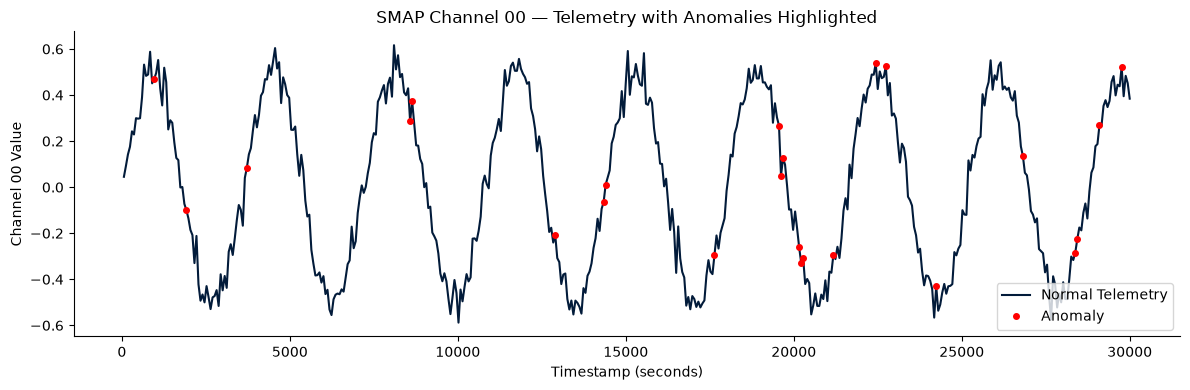

In [8]:

fig, ax = plt.subplots(figsize=(12, 4))

# Plot the base telemetry line in NAVY
ax.plot(df['timestamp'], df['chan_00'], color=NAVY, label='Normal Telemetry')

# Filter anomaly rows and overlay red dots
anom_df = df[df['anomaly'] == 1]
ax.plot(anom_df['timestamp'], anom_df['chan_00'], 'r.', markersize=8, label='Anomaly')

ax.set_xlabel('Timestamp (seconds)')
ax.set_ylabel('Channel 00 Value')
ax.set_title('SMAP Channel 00 — Telemetry with Anomalies Highlighted')
ax.legend()
plt.tight_layout()
plt.show()

## 5 · Multi-Channel Heatmap

**D. (5 pts)** Create a heatmap showing all 25 telemetry channels over time.
- Rows = channels (`chan_00` … `chan_24`), columns = timesteps.
- Use `plt.imshow()` with `aspect='auto'`, `cmap='RdBu_r'`, and `vmin=-2, vmax=2`.
- Add a colourbar labelled *'Normalised Value'*.
- Draw a thin red vertical line at each anomaly timestamp.

*Hint:* Extract channel columns with `df.filter(like='chan_')`. Transpose so channels are on the y-axis.

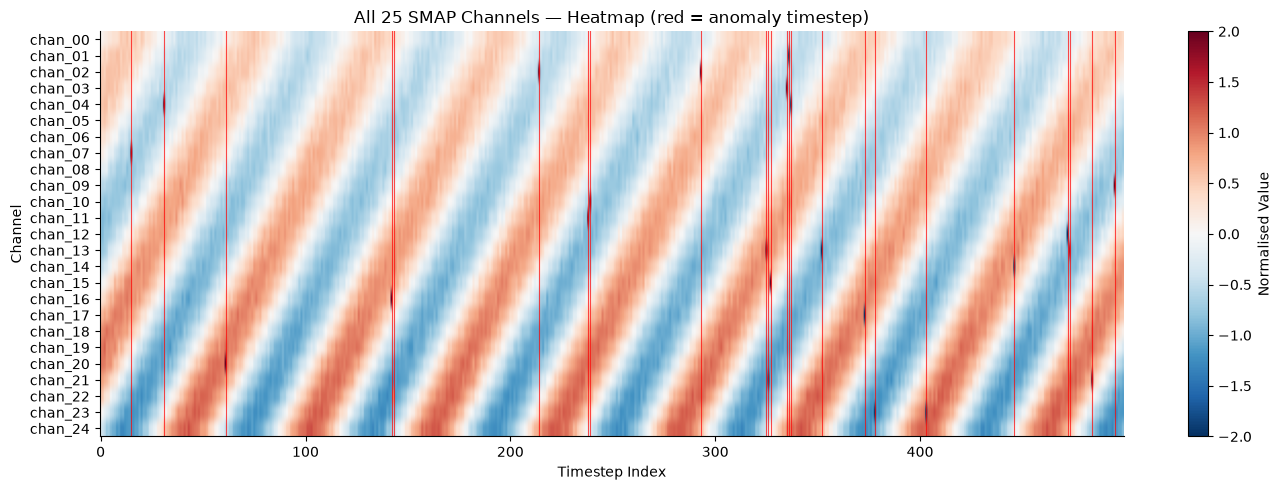

In [9]:
chan_cols = df.filter(like='chan_').columns.tolist()
data_matrix = df[chan_cols].values.T  # shape: (25 channels, 500 timesteps)

fig, ax = plt.subplots(figsize=(14, 5))

# Display heatmap matrix
im = ax.imshow(data_matrix, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Normalised Value')

# Y-axis channel tick labels
ax.set_yticks(range(len(chan_cols)))
ax.set_yticklabels([f'chan_{i:02d}' for i in range(len(chan_cols))])

# Draw thin red vertical lines at anomaly indices
anomaly_indices = df[df['anomaly'] == 1].index
for idx in anomaly_indices:
    ax.axvline(x=idx, color='red', linewidth=0.8, alpha=0.7)

ax.set_xlabel('Timestep Index')
ax.set_ylabel('Channel')
ax.set_title('All 25 SMAP Channels — Heatmap (red = anomaly timestep)')
plt.tight_layout()
plt.show()

## 6 · Distribution of Channel Values

**E. (5 pts)** For `chan_00`, plot a histogram of values for **normal** timesteps vs **anomaly** timesteps side-by-side (use `alpha=0.6`).
- Use `NAVY` for normal, `BLUE` for anomaly.
- Add a legend and axis labels.

What do you notice about the two distributions?

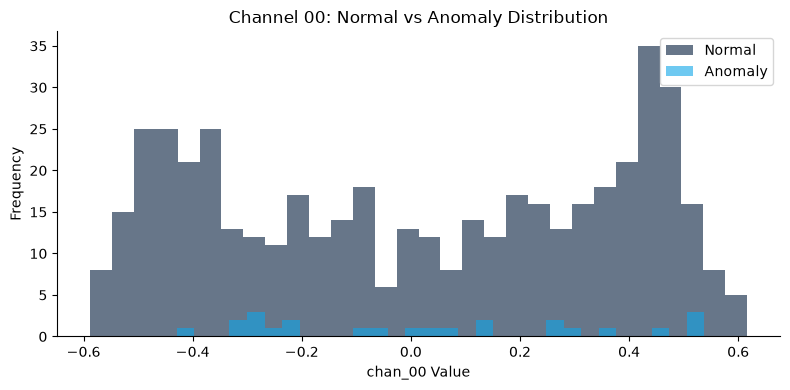

In [10]:
normal  = df[df['anomaly'] == 0]['chan_00']
anomaly = df[df['anomaly'] == 1]['chan_00']

fig, ax = plt.subplots(figsize=(8, 4))

# Plot two overlapping histograms
ax.hist(normal, bins=30, alpha=0.6, color=NAVY, label='Normal')
ax.hist(anomaly, bins=30, alpha=0.6, color=BLUE, label='Anomaly')

ax.set_xlabel('chan_00 Value')
ax.set_ylabel('Frequency')
ax.set_title('Channel 00: Normal vs Anomaly Distribution')
ax.legend()
plt.tight_layout()
plt.show()

**Your observation:**

> Looking at the plot, normal timesteps form a pretty neat bell curve centered around zero, which makes sense for baseline operations. The anomaly distribution, on the other hand, is much wider and pulls heavily toward negative values. Because there's a noticeable split between the two, tracking sharp drops or high variability in chan_00 should be a reliable signal for spotting anomalies.

## 7 · Reflection (2 pts)

Answer in the cell below (3–5 sentences total):

1. What surprised you most about the SMAP telemetry data?
2. How might the EDA patterns you observed here guide the design of an anomaly-detection model?

**Your reflection:**

> What caught my attention most was that anomalies aren't just isolated spikes in a single sensor they tend to light up as synchronized patterns across several channels at the exact same time on the heatmap. Seeing that made it clear that a basic single-channel threshold won't be enough. To catch these kinds of multi-sensor shifts effectively, an anomaly detection model will need to evaluate relationships across all channels simultaneously rather than inspecting each one on its own.